In [573]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from scikit_posthocs import posthoc_dunn
from scipy.stats import f_oneway, kruskal, ttest_rel, wilcoxon

from statannotations.Annotator import Annotator

sns.set_context("notebook", font_scale=1.5)  # Adjust font_scale to increase font size



# Analyse CFU data from community assembly 2

In [574]:
last_timepoints = [7,8]

## Read in data

In [575]:
data_folder = Path("../../data/2_second_community_assembly")
file_to_open = data_folder / "cfus.csv"
df = pd.read_csv(file_to_open, index_col=0)


In [576]:
wellmap_fn = data_folder / "wellmap.csv"
wellmap_df = pd.read_csv(wellmap_fn, index_col=0)
wellmap_df['Carbon source'] = wellmap_df['Carbon source'].str.replace('L-', '').str.replace('D-','').str.capitalize()
wellmap_df['Carbon source'] = wellmap_df['Carbon source'].str.replace('0.0', ' 0.0').str.replace('5',' 5').str.replace('+vits', ' + AA & vitamins')

well_to_cs = wellmap_df.set_index('Well').to_dict()['Carbon source']
well_to_rep = wellmap_df.set_index('Well').to_dict()['Replicate']
well_to_group = wellmap_df.set_index('Well').to_dict()['Group']

In [577]:
cs_to_group = {well_to_cs[well]: group for well, group in well_to_group.items()}


In [578]:
# Remove missing values
df = df.loc[df['CFUs/mL']!=0].copy()

In [579]:
palette = sns.palettes.color_palette('tab10')
palette = [palette[i] for i in [2,1,0,3]]

In [580]:
strains = ['At', 'Ct', 'Ml', 'Oa']

## Rename carbons sources for simplification

In [581]:
df['Carbon source'] = df['Carbon source'].str.replace('L-', '').str.replace('D-','')
df['Carbon source'] = df['Carbon source'].str.replace('0.0', ' 0.0').str.replace('5',' 5').str.replace('+vits', ' + AA & vitamins')
df.sort_values(by = 'Carbon source', inplace=True)
carbon_sources = df['Carbon source'].unique()
rich_and_control = ['LB', 'TSB', 'Vits control', 'No CS']
carbon_sources = [x for x in carbon_sources if isinstance(x, str) and x not in rich_and_control] + rich_and_control
print(carbon_sources)

['Acetate', 'Acetate + AA & vitamins', 'Acetate 0.02x', 'Acetate 5x', 'Glutamate', 'Glutamate + AA & vitamins', 'Glutamate 0.02x', 'Glutamate 5x', 'Glutarate', 'Glutarate + AA & vitamins', 'Glutarate 0.02x', 'Glutarate 5x', 'Histidine', 'Histidine + AA & vitamins', 'Histidine 0.02x', 'Histidine 5x', 'Inosine', 'Inosine + AA & vitamins', 'Inosine 0.02x', 'Inosine 5x', 'Malate', 'Malate + AA & vitamins', 'Malate 0.02x', 'Malate 5x', 'Ribose', 'Ribose + AA & vitamins', 'Ribose 0.02x', 'Ribose 5x', 'LB', 'TSB', 'Vits control', 'No CS']


In [582]:
carbon_sources_vits_only = [x for x in carbon_sources if not 'x' in str(x)]
carbon_sources_vits_only = [x for x in carbon_sources_vits_only if not x in rich_and_control]
cs_more_or_less = [x for x in carbon_sources if not '&' in x and x not in rich_and_control]



# Assess diversity across the 4 conditions


In [583]:
cs_not_rich_and_control = [x for x in carbon_sources if not x in rich_and_control]

In [584]:
def shannon(l):
    x_tot = np.sum(l)
    p = l/x_tot
    return -np.sum([pi*np.log2(pi) for pi in p])

In [585]:
wells = [x for x in df.Well.unique() if x!= 'Inoculum']
strains = ['At', 'Ct', 'Ml', 'Oa']
shannon_dict = {}
simpson_dict = {}
auxotroph_dict = {}
prototroph_dict = {}
for w in wells:
    dfw = df.loc[(df.Well==w)&(df.Batch.isin(last_timepoints))]
    abundance = {}
    for strain in strains:
        dfws = dfw.loc[dfw.Strain == strain]
        abundance[strain] = dfws['CFUs/mL'].mean()
    # print(w)
    shannon_dict[w] = shannon(list(abundance.values()))
    # simpson_dict[w] = simpson(list(abundance.values()))
    # auxotroph_dict[w] = auxotroph_abundance(abundance)
    # prototroph_dict[w] = prototroph_abundance(abundance)

In [586]:
shannon_df = pd.DataFrame(index = wells)
shannon_df['Shannon index'] = shannon_df.index.map(shannon_dict)
shannon_df['CS'] = shannon_df.index.map(well_to_cs)
shannon_df['Group'] = shannon_df.index.map(well_to_group)

shannon_df = shannon_df.loc[~shannon_df['Shannon index'].isna()].copy()



# By group

In [587]:
included_groups = ['Reference', 'With AA & vitamins', '1/50x carbon', '5x carbon']
ig_idx = shannon_df['Group'].isin(included_groups)
# Group the data by 'CS class' and extract the 'Shannon index' values for each group
# groups = [group['Shannon index'].values for name, group in shannon_df.loc[shannon_df['N CS']==1].groupby('CS class')]
groups = [group['Shannon index'].values for name, group in shannon_df.loc[ig_idx].groupby('Group')]

# Perform one-way ANOVA
f_stat, p_value = kruskal(*groups)

# Print the results
print(f"F-statistic: {f_stat}")
print(f"P-value: {p_value}")

F-statistic: 10.316925224453541
P-value: 0.016055641458912813


In [588]:

# posthoc dunn test, with correction for multiple testing
dunn_df = posthoc_dunn(
    shannon_df.loc[ig_idx], val_col="Shannon index", group_col="Group", p_adjust="fdr_bh"
)
dunn_df
remove = np.tril(np.ones(dunn_df.shape), k=0).astype("bool")
dunn_df[remove] = np.nan

molten_df = dunn_df.melt(ignore_index=False).reset_index().dropna()
molten_df

,index,variable,value
4,1/50x carbon,5x carbon,0.010688
8,1/50x carbon,Reference,0.087159
9,5x carbon,Reference,0.339328
12,1/50x carbon,With AA & vitamins,0.087159
13,5x carbon,With AA & vitamins,0.349645
14,Reference,With AA & vitamins,0.871803


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1/50x carbon vs. 5x carbon: Custom statistical test, P_val:1.069e-02


/Users/snorre/miniconda3/lib/python3.12/site-packages/statannotations/Annotator.py:786: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_62937/3425982475.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='center')


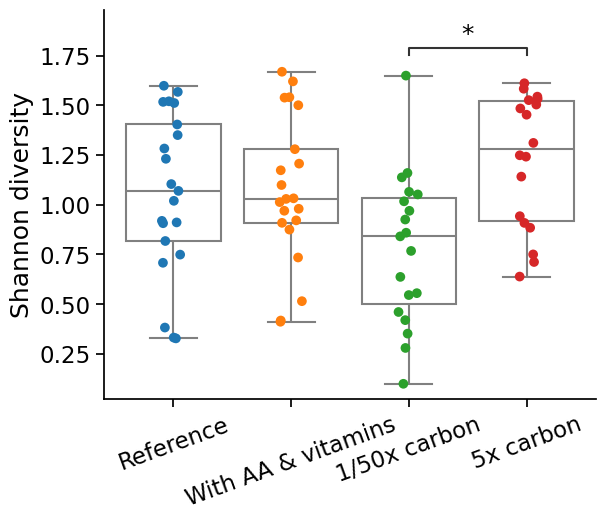

In [589]:
ax = sns.boxplot(shannon_df.loc[ig_idx], x = 'Group', y = 'Shannon index',
                #  hue = 'CS class', 
                #  boxprops = {'facecolor':'none'},
                color = 'w',
                order = included_groups,
                 legend=False,
                 linecolor='grey',
                    linewidth=1.5, 
                 fliersize=0)

sns.stripplot(shannon_df.loc[ig_idx], x = 'Group', y = 'Shannon index', 
              size=7, 
              order=included_groups,
              hue_order=included_groups,
              hue = 'Group',
              palette='tab10'
            #   hue_order=cs_classes,
            #   color = 'k'
              )

pairs = [(i[1]["index"], i[1]["variable"]) for i in molten_df.iterrows()]
p_values = [i[1]["value"] for i in molten_df.iterrows()]

annotator = Annotator(
    ax, pairs, data=shannon_df.loc[ig_idx], x="Group", y="Shannon index", order=included_groups, #orient="h" 
)
# plt.ylim(0,2)
annotator.configure(text_format="star", loc="inside",
    hide_non_significant=True, alpha=0.05)
annotator.set_pvalues_and_annotate(p_values)
sns.despine()
ax.set_ylabel('Shannon diversity')
ax.set_xlabel('')
plt.tight_layout()

ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='center')
plt.savefig('../../figures/2_second_community_assembly_shannon_diversity.pdf')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Reference vs. With AA & vitamins: Custom statistical test, P_val:8.718e-01


/Users/snorre/miniconda3/lib/python3.12/site-packages/statannotations/Annotator.py:786: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_62937/405197043.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='center')


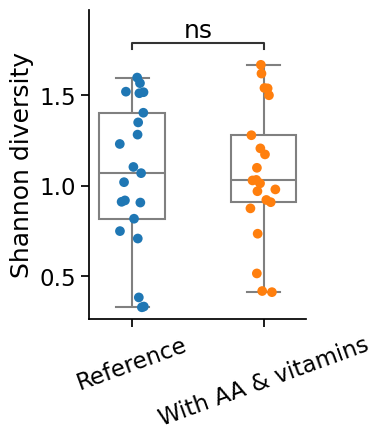

In [590]:
fig, ax = plt.subplots(figsize=(4, 4))
ig_idxvits = shannon_df['Group'].isin(['Reference', 'With AA & vitamins'])
ax = sns.boxplot(shannon_df.loc[ig_idxvits], x = 'Group', y = 'Shannon index',
                #  hue = 'CS class', 
                #  boxprops = {'facecolor':'none'},
                color = 'w',
                order = included_groups,
                 legend=False,
                 linecolor='grey',
                    linewidth=1.5, 
                  width=0.5,
                  ax=ax,
                 fliersize=0)

sns.stripplot(shannon_df.loc[ig_idxvits], x = 'Group', y = 'Shannon index', 
              size=7, 
              order=included_groups,
              hue_order=included_groups,
              hue = 'Group',
              palette='tab10'
            #   hue_order=cs_classes,
            #   color = 'k'
              )

pairs = [('Reference', 'With AA & vitamins')]
p_values = [molten_df.at[14, 'value']]

annotator = Annotator(
    ax, pairs, data=shannon_df.loc[ig_idx], x="Group", y="Shannon index", order=included_groups, #orient="h" 
)
# plt.ylim(0,2)
annotator.configure(text_format="star", loc="inside",
    hide_non_significant=False,
      alpha=0.05)
annotator.set_pvalues_and_annotate(p_values)
sns.despine()
ax.set_ylabel('Shannon diversity')
ax.set_xlabel('')
plt.tight_layout()

ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='center')
plt.savefig('../../figures/2_second_community_assembly_shannon_diversity_vits_only.pdf')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1/50x carbon vs. 5x carbon: Custom statistical test, P_val:1.069e-02


/Users/snorre/miniconda3/lib/python3.12/site-packages/statannotations/Annotator.py:786: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_62937/2444456214.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='center')


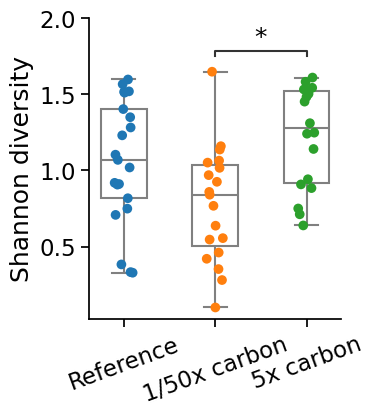

In [591]:
fig, ax = plt.subplots(figsize=(4, 4))
ig_idxvits = shannon_df['Group'].isin(['Reference', '1/50x carbon', '5x carbon'])
ax = sns.boxplot(shannon_df.loc[ig_idxvits], x = 'Group', y = 'Shannon index',
                #  hue = 'CS class', 
                #  boxprops = {'facecolor':'none'},
                color = 'w',
                # order = included_groups,
                 legend=False,
                 linecolor='grey',
                    linewidth=1.5, 
                  width=0.5,
                  ax=ax,
                 fliersize=0)

sns.stripplot(shannon_df.loc[ig_idxvits], x = 'Group', y = 'Shannon index', 
              size=7, 
            #   order=included_groups,
            #   hue_order=included_groups,
              hue = 'Group',
              palette='tab10'
            #   hue_order=cs_classes,
            #   color = 'k'
              )

pairs = [('1/50x carbon', '5x carbon')]
p_values = [molten_df.at[4, 'value']]

annotator = Annotator(
    ax, pairs, data=shannon_df.loc[ig_idxvits], x="Group", y="Shannon index",
    #   order=included_groups, #orient="h" 
)
# plt.ylim(0,2)
annotator.configure(text_format="star", loc="inside",
    hide_non_significant=False,
      alpha=0.05)
annotator.set_pvalues_and_annotate(p_values)
sns.despine()
ax.set_ylabel('Shannon diversity')
ax.set_xlabel('')
plt.tight_layout()

ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='center')
plt.savefig('../../figures/2_second_community_assembly_shannon_diversity_x_only.pdf')

# Compute ranks

In [592]:
df_mean78 = df.loc[df.Batch.isin(last_timepoints)].groupby(['Strain', 'Carbon source']).agg({'CFUs/mL':['mean', 'std']}).reset_index()    

# Group by 'Carbon source' and rank species by abundance
df_mean78[('Abundance rank', '')] = df_mean78.groupby([('Carbon source', '')]).rank(ascending=False, method='min')[( 'CFUs/mL', 'mean')]
df_mean78.columns = ['Species', 'Carbon source', 'Mean CFUs/mL', 'Std CFUs/mL', 'Abundance rank']
df_mean78['Group'] = df_mean78['Carbon source'].map(cs_to_group)

In [593]:
df_mean78['Carbon source'].values[1]

'Acetate + AA & vitamins'

In [594]:
cs_to_group

{'Acetate': 'Reference',
 'Acetate + AA & vitamins': 'With AA & vitamins',
 'Acetate 5x': '5x carbon',
 'Acetate 0.02x': '1/50x carbon',
 'Glutarate': 'Reference',
 'Glutarate + AA & vitamins': 'With AA & vitamins',
 'Glutarate 5x': '5x carbon',
 'Glutarate 0.02x': '1/50x carbon',
 'Inosine': 'Reference',
 'Inosine + AA & vitamins': 'With AA & vitamins',
 'Inosine 5x': '5x carbon',
 'Inosine 0.02x': '1/50x carbon',
 'Glutamate': 'Reference',
 'Glutamate + AA & vitamins': 'With AA & vitamins',
 'Glutamate 5x': '5x carbon',
 'Glutamate 0.02x': '1/50x carbon',
 'Histidine': 'Reference',
 'Histidine + AA & vitamins': 'With AA & vitamins',
 'Histidine 5x': '5x carbon',
 'Histidine 0.02x': '1/50x carbon',
 'Malate': 'Reference',
 'Malate + AA & vitamins': 'With AA & vitamins',
 'Malate 5x': '5x carbon',
 'Malate 0.02x': '1/50x carbon',
 'Ribose': 'Reference',
 'Ribose + AA & vitamins': 'With AA & vitamins',
 'Ribose 5x': '5x carbon',
 'Ribose 0.02x': '1/50x carbon',
 'No cs': 'Control',
 'Vi

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_62937/2427635269.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='center')


[Text(0, 0, 'Reference'),
 Text(1, 0, 'With AA & vitamins'),
 Text(2, 0, '1/50x carbon'),
 Text(3, 0, '5x carbon')]

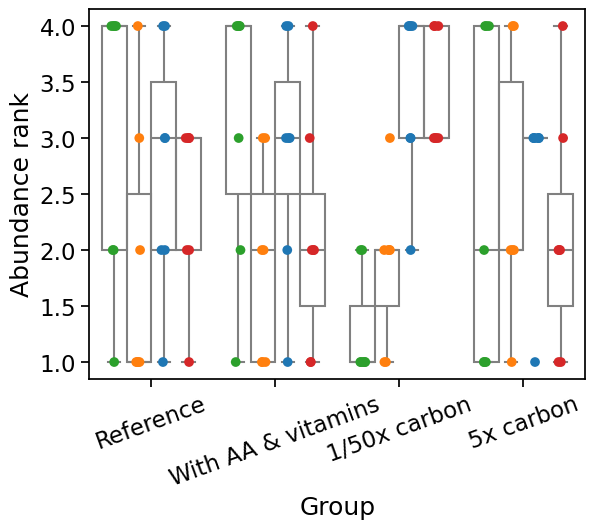

In [595]:
idx = df_mean78['Group'].isin(['Reference', 'With AA & vitamins', '1/50x carbon', '5x carbon'])
ax = sns.boxplot(df_mean78.loc[idx], x = 'Group', y = 'Abundance rank',
            hue= 'Species', hue_order=strains,palette=palette,legend=False,
            color = 'w',
            dodge=True,
                 linecolor='grey',
                    linewidth=1.5, 
                 boxprops = {'facecolor':'none'},
                 fliersize=0)

sns.stripplot(df_mean78.loc[idx], x = 'Group', y = 'Abundance rank',
              size=7, 
              hue = 'Species', hue_order=strains,
              dodge=True,
              palette=palette,
              legend=   False,
            #   color = 'k'
              ) 
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='center')


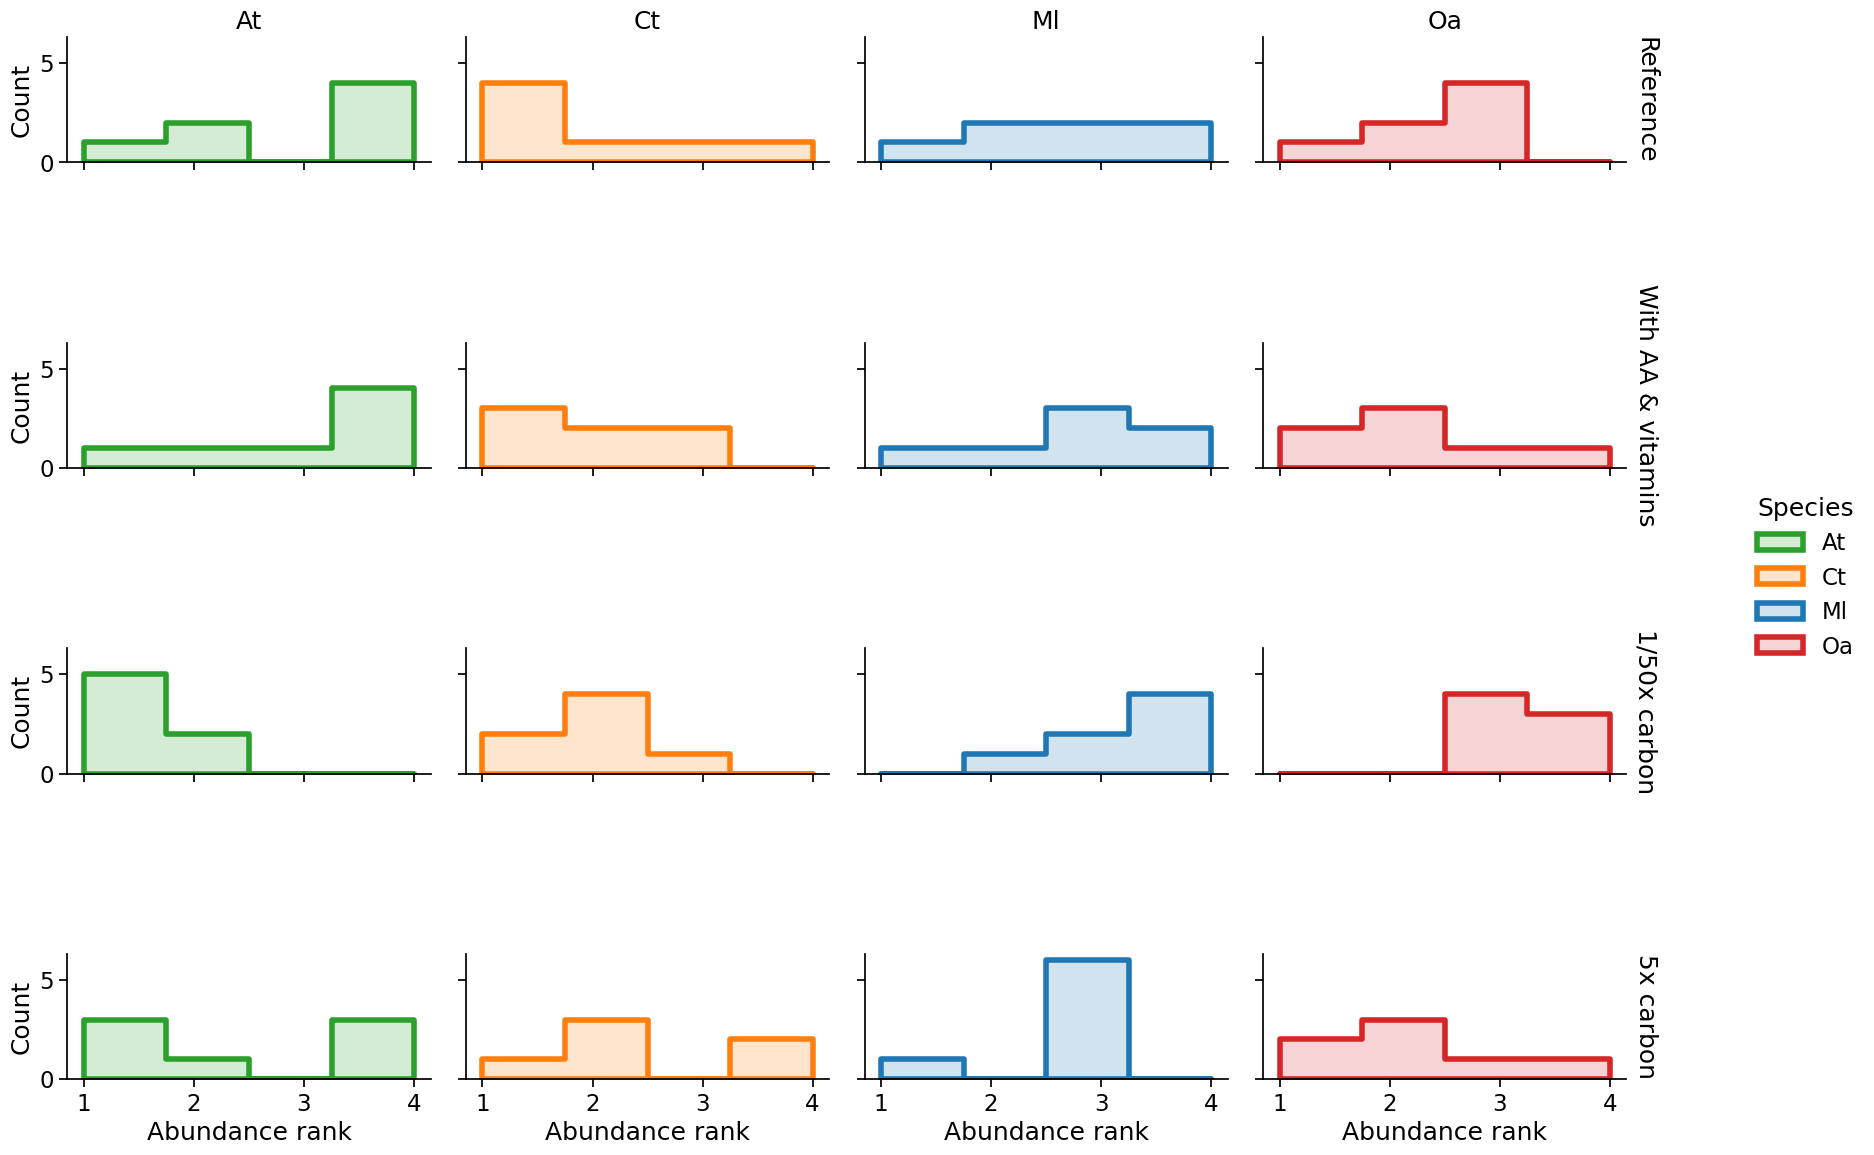

In [596]:
g = sns.displot(df_mean78.loc[idx], x = 'Abundance rank', hue = 'Species', 
            hue_order=strains, col = 'Species',
            col_order=strains,
            palette=palette,
            # kind='kde',
            kind='hist',
            alpha = 0.2,
            element='step',
            row = 'Group',

            # hue_order=['Reference', '5x carbon', 'With AA & vitamins', '1/50x carbon'],
            # multiple='kde',
            lw=4,
            bins=4,
            # gridsize=4,
            # ls = '--',
            facet_kws={'margin_titles': True},  # Add row titles in the left margin
            height=3,
            aspect=1.5,
            )
# plt.xlim(1, 4)
# Remove y-axis ticks and labels
# g.set(yticks=[], ylabel=None)

# Remove subplot titles
g.set_titles(row_template="{row_name}", col_template="{col_name}")



In [597]:
species_to_auxotroph = {'At': 'Prototroph',
                        'Ct': 'Prototroph',
                        'Ml': 'Auxotroph',
                        'Oa': 'Auxotroph'}
df_mean78['Auxotroph'] = df_mean78['Species'].map(species_to_auxotroph)

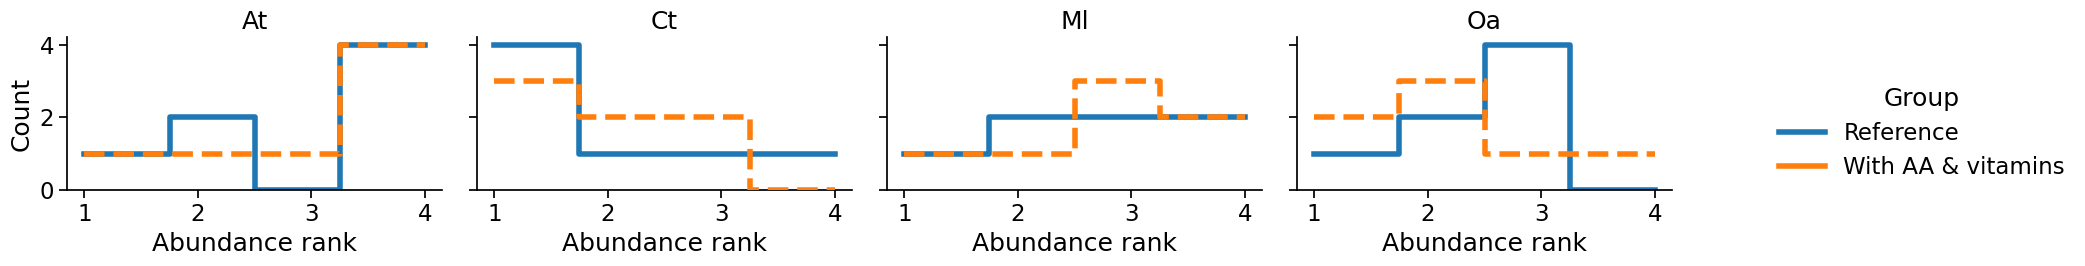

In [598]:
idx = df_mean78['Group'].isin(['Reference', 'With AA & vitamins'])
g = sns.displot(df_mean78.loc[idx], x = 'Abundance rank', 
                hue = 'Group', 
            hue_order=['Reference', 'With AA & vitamins'],
            col = 'Species',
            col_order=strains,
            # palette=palette,
            # kind='kde',
            kind='hist',
            # alpha = 0.2,
            element='step',
            # row = 'Group',

            # hue_order=['Reference', '5x carbon', 'With AA & vitamins', '1/50x carbon'],
            # multiple='kde',
            lw=4,
            bins=4,
            # gridsize=4,
            # ls = '--',
            facet_kws={'margin_titles': True},  # Add row titles in the left margin
            height=3,
            aspect=1.5,
            fill=False,
            )
# plt.xlim(1, 4)
# Remove y-axis ticks and labels
# g.set(yticks=[], ylabel=None)
for ax in g.axes.flat:
    for line, group in zip(ax.lines, ['Reference', 'With AA & vitamins']):
        if group == 'Reference':
            line.set_linestyle('--')  # Set dashed line for this group
            line.set_zorder(100)  # Set zorder for dashed line
        else:
            line.set_linestyle('-')  # Set solid line for this group

# Remove subplot titles
g.set_titles(row_template="{row_name}", col_template="{col_name}")
plt.savefig('../../figures/2_second_community_assembly_abundance_rank_hist_vitamins.pdf')


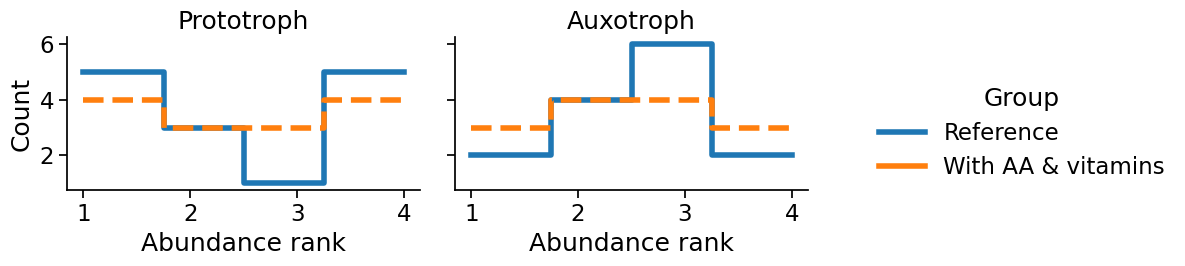

In [599]:
idx = df_mean78['Group'].isin(['Reference', 'With AA & vitamins'])
g = sns.displot(df_mean78.loc[idx], x = 'Abundance rank', 
                hue = 'Group', 
            hue_order=['Reference', 'With AA & vitamins'],
            col = 'Auxotroph',
            # col_order=strains,
            # palette=palette,
            # kind='kde',
            kind='hist',
            # alpha = 0.2,
            element='step',
            # row = 'Group',

            # hue_order=['Reference', '5x carbon', 'With AA & vitamins', '1/50x carbon'],
            # multiple='kde',
            lw=4,
            bins=4,
            # gridsize=4,
            # ls = '--',
            facet_kws={'margin_titles': True},  # Add row titles in the left margin
            height=3,
            aspect=1.5,
            fill=False,
            )
# plt.xlim(1, 4)
# Remove y-axis ticks and labels
# g.set(yticks=[], ylabel=None)
for ax in g.axes.flat:
    for line, group in zip(ax.lines, ['Reference', 'With AA & vitamins']):
        if group == 'Reference':
            line.set_linestyle('--')  # Set dashed line for this group
            line.set_zorder(100)  # Set zorder for dashed line
        else:
            line.set_linestyle('-')  # Set solid line for this group

# Remove subplot titles
g.set_titles(row_template="{row_name}", col_template="{col_name}")
plt.savefig('../../figures/2_second_community_assembly_abundance_rank_hist_vitamins_auxo_proto.pdf')


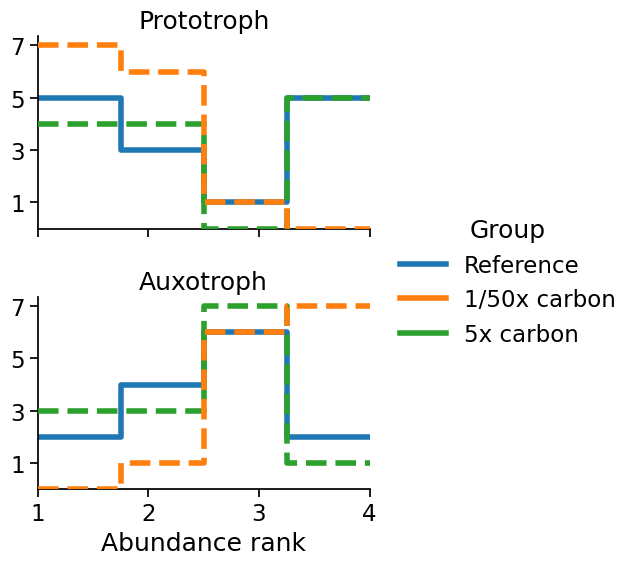

In [600]:
idx = df_mean78['Group'].isin(['Reference', '1/50x carbon', '5x carbon'])
g = sns.displot(df_mean78.loc[idx], x = 'Abundance rank', 
                hue = 'Group', 
            hue_order=['Reference', '1/50x carbon', '5x carbon'],
            col = 'Auxotroph',
            # col_order=strains,
            col_wrap=1,
            # palette=palette,
            # kind='kde',
            kind='hist',
            # alpha = 0.2,
            element='step',
            # row = 'Group',

            # hue_order=['Reference', '5x carbon', 'With AA & vitamins', '1/50x carbon'],
            # multiple='kde',
            lw=4,
            bins=4,
            # gridsize=4,
            # ls = '--',
            # facet_kws={'margin_titles': True},  # Add row titles in the left margin
            height=3,
            aspect=1.5,
            fill=False,
            )
plt.xlim(1, 4)
# Remove y-axis ticks and labels
g.set(yticks=[1,3,5,7], ylabel=None)
for ax in g.axes.flat:
    for line, group in zip(ax.lines, ['5x carbon',  '1/50x carbon', 'Reference']):
        if group in ['5x carbon', '1/50x carbon']:
            line.set_linestyle('--')  # Set dashed line for this group
            line.set_zorder(100)  # Set zorder for dashed line
        else:
            line.set_linestyle('-')  # Set solid line for this group
# g.set(yticks=[1, 3, 5])

# Remove subplot titles
g.set_titles(row_template="{row_name}", col_template="{col_name}")
plt.savefig('../../figures/2_second_community_assembly_abundance_rank_hist_x_carbon_auxo_proto.pdf')


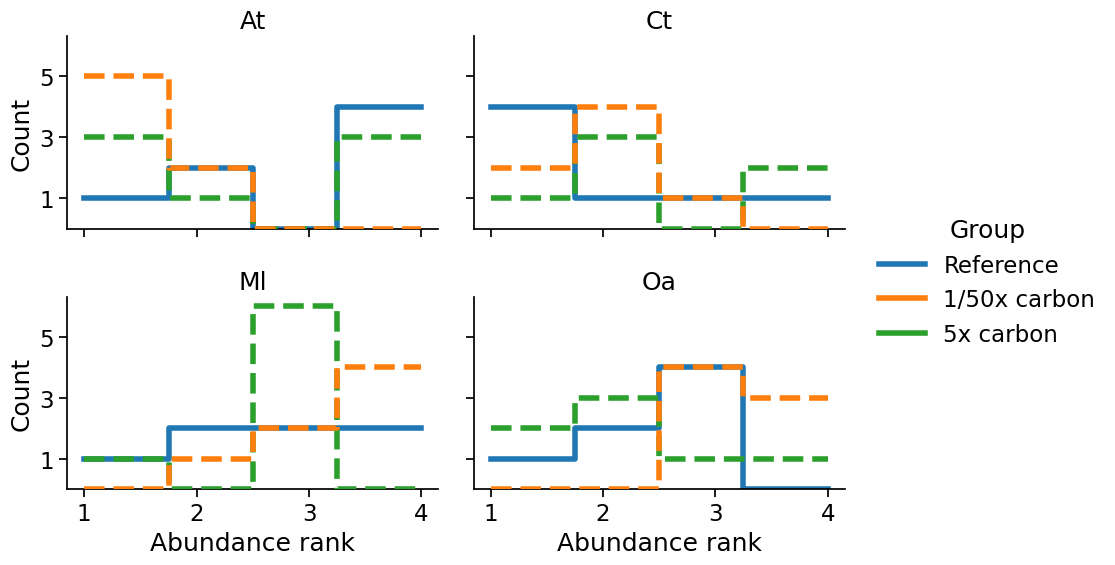

In [601]:
idx = df_mean78['Group'].isin(['Reference', '1/50x carbon', '5x carbon'])
g = sns.displot(df_mean78.loc[idx], x = 'Abundance rank', 
                hue = 'Group', 
            hue_order=['Reference', '1/50x carbon', '5x carbon'],
            col = 'Species',
            col_order=strains,
            col_wrap=2,
            # palette=palette,
            # kind='kde',
            kind='hist',
            # alpha = 0.2,
            element='step',
            # row = 'Group',

            # hue_order=['Reference', '5x carbon', 'With AA & vitamins', '1/50x carbon'],
            # multiple='kde',
            lw=4,
            bins=4,
            # gridsize=4,
            # ls = '--',
            facet_kws={'margin_titles': True},  # Add row titles in the left margin
            height=3,
            aspect=1.5,
            fill=False,
            )
# plt.xlim(1, 4)
# Remove y-axis ticks and labels
# g.set(yticks=[], ylabel=None)
for ax in g.axes.flat:
    for line, group in zip(ax.lines, ['5x carbon',  '1/50x carbon', 'Reference']):
        if group in ['5x carbon', '1/50x carbon']:
            line.set_linestyle('--')  # Set dashed line for this group
            line.set_zorder(100)  # Set zorder for dashed line
        else:
            line.set_linestyle('-')  # Set solid line for this group
g.set(yticks=[1, 3, 5])

# Remove subplot titles
g.set_titles(row_template="{row_name}", col_template="{col_name}")
plt.savefig('../../figures/2_second_community_assembly_abundance_rank_hist_x_carbon.pdf')


In [602]:
df_mean78.loc[df_mean78.Species=='Oa']

,Species,Carbon source,Mean CFUs/mL,Std CFUs/mL,Abundance rank,Group,Auxotroph
95,Oa,Acetate,7.000000e+07,6.663332e+07,3.0,Reference,Auxotroph
96,Oa,Acetate + AA & vitamins,1.233333e+09,7.089899e+08,1.0,With AA & vitamins,Auxotroph
97,Oa,Acetate 0.02x,1.606000e+06,2.455119e+06,3.0,1/50x carbon,Auxotroph
98,Oa,Acetate 5x,2.800000e+09,9.879271e+08,1.0,5x carbon,Auxotroph
99,Oa,Glutamate,7.733333e+07,6.388323e+07,3.0,Reference,Auxotroph
100,Oa,Glutamate + AA & vitamins,9.633333e+08,3.688722e+08,2.0,With AA & vitamins,Auxotroph
101,Oa,Glutamate 0.02x,2.433333e+06,1.127239e+06,3.0,1/50x carbon,Auxotroph
102,Oa,Glutamate 5x,1.480000e+09,9.011104e+08,3.0,5x carbon,Auxotroph
103,Oa,Glutarate,1.050000e+09,8.530182e+08,2.0,Reference,Auxotroph
104,Oa,Glutarate + AA & vitamins,1.266667e+08,2.732520e+07,4.0,With AA & vitamins,Auxotroph


In [603]:
df_mean78['Base carbon source'] = df_mean78['Carbon source'].str.split(' ').str[0]

/Users/snorre/miniconda3/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  self._figure.tight_layout(*args, **kwargs)
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_62937/3967996024.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_62937/3967996024.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_62937/3967996024.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipyk

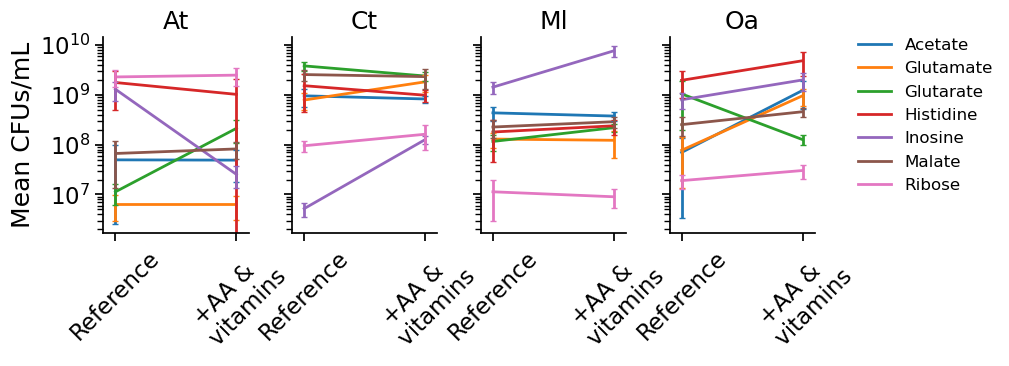

In [604]:
idxg = df_mean78['Group'].isin(['Reference', 'With AA & vitamins'])
# fig, ax = plt.subplots(figsize=(2, 6))
s = 'Oa'
g = sns.relplot(df_mean78.loc[idxg], x = 'Group', y = 'Mean CFUs/mL', hue = 'Base carbon source', kind='line', col = 'Species', palette='tab10', 
            legend=True, err_style='bars',
            height=4, 
            lw=2,
            aspect=0.4)#, errorbar=('ci', 'Std CFUs/mL'))
# Add custom error bars manually
for ax, (species, group_data) in zip(g.axes.flat, df_mean78.loc[idxg].groupby('Species')):
    for hue_value, hue_group in group_data.groupby('Base carbon source'):
        # Sort the data by the x-axis variable
        hue_group = hue_group.sort_values(by='Group')

        # Plot the error bars
        ax.errorbar(
            hue_group['Group'],
            hue_group['Mean CFUs/mL'],
            yerr=hue_group['Std CFUs/mL'],  # Use the standard deviation column for error bars
            fmt='none',  # Do not plot additional points
            ecolor=sns.color_palette('tab10')[list(df_mean78.loc[idxg]['Base carbon source'].unique()).index(hue_value)],
            alpha=1,
            elinewidth=2,
            capsize=2
        )

# sns.lineplot(df_mean78.loc[idxg], x = 'Group', y = 'Mean CFUs/mL', hue = 'Base carbon source', legend=False,err_style='bars')
plt.yscale('log')
for ax in g.axes.flat:
    ax.set_xticklabels(
        [label.get_text().replace('With AA & vitamins', '+AA & \n vitamins') for label in ax.get_xticklabels()],  # Replace spaces with line breaks
        rotation=45, ha='center')
    ax.set_xlim(-0.1, 1.1)
    ax.set_xlabel('')
plt.tight_layout()
# Remove 'Species' from the titles
g.set_titles("{col_name}")  # Only show the value of the 'Species' column
plt.subplots_adjust(wspace=0.3, hspace=0.3)  # Reduce horizontal and vertical spacing
sns.move_legend(g, "upper left", bbox_to_anchor=(0.95, .9), fontsize=12, title='')

In [605]:
ref_carbon_sources = sorted(df_mean78.loc[df_mean78.Group=='Reference']['Carbon source'].unique())
diff_data = []
for s in strains:
    print(s)
    for cs in ref_carbon_sources:
        ref_mean = df_mean78.loc[(df_mean78['Carbon source'] == cs) & (df_mean78['Species'] == s), 'Mean CFUs/mL'] 
        plus_vits_mean = df_mean78.loc[(df_mean78['Carbon source'] == cs + ' + AA & vitamins') & (df_mean78['Species'] == s), 'Mean CFUs/mL']
        # print(f"{cs}: {ref_mean.values[0]} vs {plus_vits_mean.values[0]}")
        log_diff  = np.log10(plus_vits_mean.values[0]) - np.log10(ref_mean.values[0])
        diff  = plus_vits_mean.values[0] - ref_mean.values[0]
        rel_diff = diff / ref_mean.values[0]
        rel_log_diff = log_diff / np.log10(ref_mean.values[0])
        diff_data.append([cs, s, diff,rel_diff, log_diff, rel_log_diff, ref_mean.values[0], plus_vits_mean.values[0]])   

diff_df = pd.DataFrame(diff_data, columns=['Carbon source', 'Species', 'Difference', 'Relative difference', 'Log difference', 'Relative log difference', 'Ref CFUs/mL', 'Plus vits CFUs/mL'])   

At
Ct
Ml
Oa


In [606]:
diff_df.loc[diff_df['Relative difference']>0].groupby('Species').count()

,Carbon source,Difference,Relative difference,Log difference,Relative log difference,Ref CFUs/mL,Plus vits CFUs/mL
Species,,,,,,,
At,3,3,3,3,3,3,3
Ct,3,3,3,3,3,3,3
Ml,4,4,4,4,4,4,4
Oa,6,6,6,6,6,6,6


## Relative abundance

In [607]:
df.head()

,Well,Batch,CFUs/mL,Strain,Carbon source,Replicate
1,A1,1,1.600000e+08,At,Acetate,1.0
1251,A2,6,1.000000e+09,Ct,Acetate,2.0
1252,A3,6,6.000000e+08,Ct,Acetate,3.0
1346,A1,7,1.600000e+09,Ct,Acetate,1.0
1347,A2,7,8.000000e+08,Ct,Acetate,2.0


In [608]:
df['Total population'] = df.groupby(['Batch', 'Well'])['CFUs/mL'].transform('sum')
df['Rel. population'] = df['CFUs/mL'] / df['Total population']
df_rel78 = df.loc[df.Batch.isin(last_timepoints)].groupby(['Strain', 'Carbon source']).agg({'Rel. population':['mean', 'std']}).reset_index()    
df_rel78['Group'] = df_rel78['Carbon source'].map(cs_to_group)
df_rel78['Base carbon source'] = df_rel78['Carbon source'].str.split(' ').str[0]
df_rel78.columns = ['Species', 'Carbon source', 'Mean rel. population', 'Std rel. population', 'Group', 'Base carbon source']

/Users/snorre/miniconda3/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  self._figure.tight_layout(*args, **kwargs)
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_62937/2143883066.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_62937/2143883066.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_62937/2143883066.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipyk

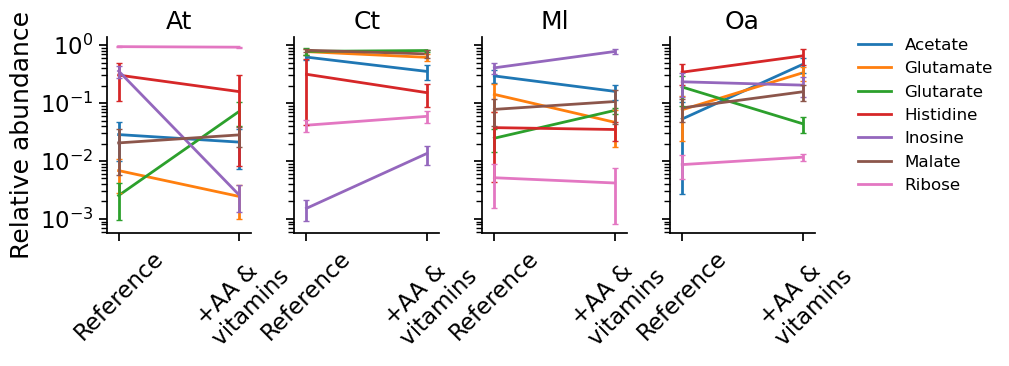

In [609]:
idxg = df_rel78['Group'].isin(['Reference', 'With AA & vitamins'])
# fig, ax = plt.subplots(figsize=(2, 6))
s = 'Oa'
g = sns.relplot(df_rel78.loc[idxg], x = 'Group', y = 'Mean rel. population', hue = 'Base carbon source', kind='line', col = 'Species', palette='tab10', 
            legend=True, err_style='bars',
            height=4, 
            lw=2,
            aspect=0.4)#, errorbar=('ci', 'Std CFUs/mL'))
# Add custom error bars manually
for ax, (species, group_data) in zip(g.axes.flat, df_rel78.loc[idxg].groupby('Species')):
    for hue_value, hue_group in group_data.groupby('Base carbon source'):
        # Sort the data by the x-axis variable
        hue_group = hue_group.sort_values(by='Group')

        # Plot the error bars
        ax.errorbar(
            hue_group['Group'],
            hue_group['Mean rel. population'],
            yerr=hue_group['Std rel. population'],  # Use the standard deviation column for error bars
            fmt='none',  # Do not plot additional points
            ecolor=sns.color_palette('tab10')[list(df_rel78.loc[idxg]['Base carbon source'].unique()).index(hue_value)],
            alpha=1,
            elinewidth=2,
            capsize=2
        )

# sns.lineplot(df_rel78.loc[idxg], x = 'Group', y = 'Rel. population', hue = 'Base carbon source', legend=False,err_style='bars')
plt.yscale('log')
for ax in g.axes.flat:
    ax.set_xticklabels(
        [label.get_text().replace('With AA & vitamins', '+AA & \n vitamins') for label in ax.get_xticklabels()],  # Replace spaces with line breaks
        rotation=45, ha='center')
    ax.set_xlim(-0.1, 1.1)
    ax.set_xlabel('')
plt.tight_layout()
# Remove 'Species' from the titles
g.set_titles("{col_name}")  # Only show the value of the 'Species' column
plt.subplots_adjust(wspace=0.3, hspace=0.3)  # Reduce horizontal and vertical spacing
sns.move_legend(g, "upper left", bbox_to_anchor=(0.95, .9), fontsize=12, title='')
g.set_ylabels('Relative abundance')
plt.savefig('../../figures/2_second_community_assembly_relative_abundance.pdf')

In [610]:
ref_carbon_sources = sorted(df_rel78.loc[df_rel78.Group=='Reference']['Carbon source'].unique())
diff_data_rel = []
for s in strains:
    print(s)
    for cs in ref_carbon_sources:
        ref_mean = df_rel78.loc[(df_rel78['Carbon source'] == cs) & (df_rel78['Species'] == s), 'Mean rel. population'] 
        plus_vits_mean = df_rel78.loc[(df_rel78['Carbon source'] == cs + ' + AA & vitamins') & (df_rel78['Species'] == s), 'Mean rel. population']
        # print(f"{cs}: {ref_mean.values[0]} vs {plus_vits_mean.values[0]}")
        log_diff  = np.log10(plus_vits_mean.values[0]) - np.log10(ref_mean.values[0])
        diff  = plus_vits_mean.values[0] - ref_mean.values[0]
        rel_diff = diff / ref_mean.values[0]
        rel_log_diff = log_diff / np.log10(ref_mean.values[0])
        diff_data_rel.append([cs, s, diff,rel_diff, log_diff, rel_log_diff, ref_mean.values[0], plus_vits_mean.values[0]])   

diff_df_rel = pd.DataFrame(diff_data_rel, columns=['Carbon source', 'Species', 'Difference', 'Relative difference', 'Log difference', 'Relative log difference', 'Ref CFUs/mL', 'Plus vits CFUs/mL'])   

At
Ct
Ml
Oa


In [611]:
diff_df.loc[diff_df['Relative difference']>0].groupby('Species').count()

,Carbon source,Difference,Relative difference,Log difference,Relative log difference,Ref CFUs/mL,Plus vits CFUs/mL
Species,,,,,,,
At,3,3,3,3,3,3,3
Ct,3,3,3,3,3,3,3
Ml,4,4,4,4,4,4,4
Oa,6,6,6,6,6,6,6


In [612]:
diff_df.groupby('Species').agg({'Difference':['mean', 'std', 'median'], 'Relative difference':['mean', 'std'], 'Log difference':['mean', 'std'], 'Relative log difference':['mean', 'std']}).reset_index()   

Species    Difference                            Relative difference  \
                   mean           std       median                mean   
0      At -2.296667e+08  5.625978e+08          0.0            2.389916   
1      Ct -1.587905e+08  7.478770e+08 -130000000.0            3.489384   
2      Ml  9.177143e+08  2.359298e+09   60000000.0            0.782323   
3      Oa  7.777143e+08  1.200684e+09  886000000.0            4.511919   

            Log difference           Relative log difference            
        std           mean       std                    mean       std  
0  6.817855      -0.078817  0.873004               -0.002555  0.106954  
1  8.783913       0.212003  0.559619                0.031862  0.080628  
2  1.626792       0.149898  0.287007                0.016752  0.032225  
3  6.722726       0.382363  0.706431                0.048806  0.085362

In [613]:
differences = diff_df.loc[diff_df.Species == 'Ml', 'Difference'].values
wilcoxon(differences)

WilcoxonResult(statistic=np.float64(6.5), pvalue=np.float64(0.234375))

<Axes: xlabel='Species', ylabel='Relative difference'>

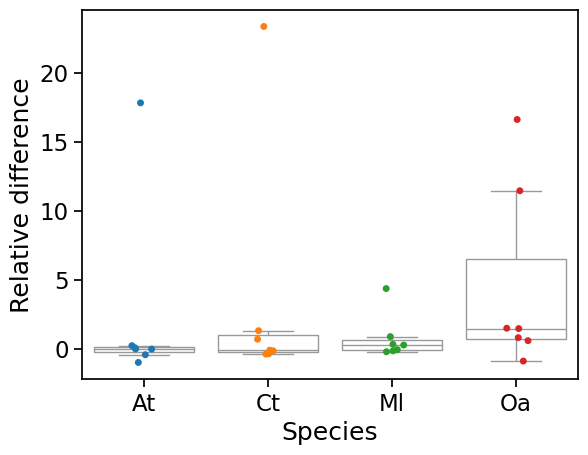

In [614]:
sns.boxplot(diff_df, x = 'Species', y = 'Relative difference', color = 'w', fliersize=0)
sns.stripplot(diff_df, x = 'Species', y = 'Relative difference', hue = 'Species', palette='tab10')
# plt.ylim(-5, 5)

In [615]:
df.loc[(df['Carbon source']=='Histidine + AA & vitamins')&(df['Strain']=='At')].sort_values(by='CFUs/mL', ascending=False)


,Well,Batch,CFUs/mL,Strain,Carbon source,Replicate,Total population,Rel. population
628,E4,7,3.000000e+09,At,Histidine + AA & vitamins,1.0,7.560000e+09,0.396825
150,E6,2,1.200000e+09,At,Histidine + AA & vitamins,3.0,5.360000e+09,0.223881
724,E4,8,1.160000e+09,At,Histidine + AA & vitamins,1.0,4.120000e+09,0.281553
149,E5,2,1.000000e+09,At,Histidine + AA & vitamins,2.0,3.900000e+09,0.256410
244,E4,3,1.000000e+09,At,Histidine + AA & vitamins,1.0,6.080000e+09,0.164474
532,E4,6,8.200000e+08,At,Histidine + AA & vitamins,1.0,7.560000e+09,0.108466
629,E5,7,8.000000e+08,At,Histidine + AA & vitamins,2.0,6.860000e+09,0.116618
725,E5,8,8.000000e+08,At,Histidine + AA & vitamins,2.0,7.860000e+09,0.101781
341,E5,4,8.000000e+08,At,Histidine + AA & vitamins,2.0,6.420000e+09,0.124611
436,E4,5,7.800000e+08,At,Histidine + AA & vitamins,1.0,5.220000e+09,0.149425


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_62937/3996023994.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='center')


(-0.5, 1.5)

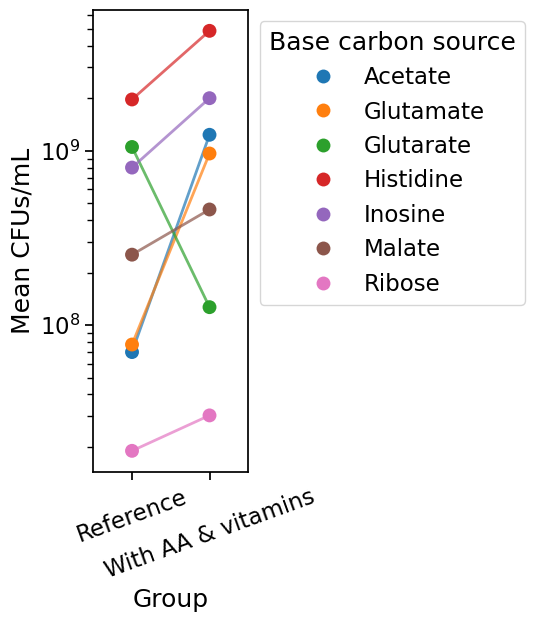

In [616]:
idxg = df_mean78['Group'].isin(['Reference', 'With AA & vitamins'])
fig, ax = plt.subplots(figsize=(2, 6))
ax = sns.stripplot(df_mean78.loc[idxg&(df_mean78.Species=='Oa')], x = 'Group', y = 'Mean CFUs/mL', 
                   hue = 'Base carbon source',legend=True, size=10, jitter=False, palette='tab10', ax = ax)
plt.yscale('log')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='center')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), title="Base carbon source",ncol=1,)
# Draw lines between points of the same hue
for i, (hue_value, group_data) in enumerate(df_mean78.loc[idxg & (df_mean78.Species == 'Oa')].groupby('Base carbon source')):
    # Sort the data by the x-axis variable to ensure proper line connections
    group_data = group_data.sort_values(by='Group')
    ax.plot(
        group_data['Group'],
        group_data['Mean CFUs/mL'],
        marker='o',
        linestyle='-',
        lw = 2,
        color=f'C{i}',
        alpha=0.7
    )

plt.xlim(-0.5, 1.5)

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_62937/2032304881.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='center')


(-0.5, 1.5)

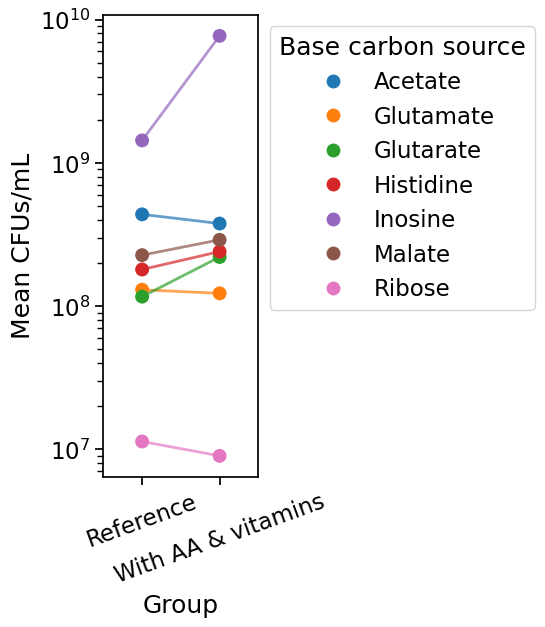

In [617]:
idxg = df_mean78['Group'].isin(['Reference', 'With AA & vitamins'])
fig, ax = plt.subplots(figsize=(2, 6))
ax = sns.stripplot(df_mean78.loc[idxg&(df_mean78.Species=='Ml')], x = 'Group', y = 'Mean CFUs/mL', 
                   hue = 'Base carbon source',legend=True, size=10, jitter=False, palette='tab10', ax = ax)
plt.yscale('log')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='center')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), title="Base carbon source",ncol=1,)
# Draw lines between points of the same hue
for i, (hue_value, group_data) in enumerate(df_mean78.loc[idxg & (df_mean78.Species == 'Ml')].groupby('Base carbon source')):
    # Sort the data by the x-axis variable to ensure proper line connections
    group_data = group_data.sort_values(by='Group')
    ax.plot(
        group_data['Group'],
        group_data['Mean CFUs/mL'],
        marker='o',
        linestyle='-',
        lw = 2,
        color=f'C{i}',
        alpha=0.7
    )

plt.xlim(-0.5, 1.5)

# More or less carbon

In [639]:
base_cs_list = df_mean78['Base carbon source'].unique()
base_cs_list = [x for x in base_cs_list if not x in ['LB', 'No', 'TSB', 'Vits']]


In [665]:
rel_increase_data =[]
for cs in base_cs_list:
    for s in strains:
        high = f'{cs} 5x'
        low = f'{cs} 0.02x'
        # print(cs, s)
        low_val = df_mean78.loc[(df_mean78['Carbon source'] == low) & (df_mean78['Species'] == s), 'Mean CFUs/mL'].values[0]
        try:
            high_val = df_mean78.loc[(df_mean78['Carbon source'] == high) & (df_mean78['Species'] == s), 'Mean CFUs/mL'].values[0]
        except IndexError:
            high_val = np.nan
        ref_val = df_mean78.loc[(df_mean78['Carbon source'] == cs) & (df_mean78['Species'] == s), 'Mean CFUs/mL'].values[0]
        rel_increase_data.append([cs, s, low_val/ref_val, high_val/ref_val, high_val/low_val])

In [666]:
df_rel_increase = pd.DataFrame(rel_increase_data, columns=['Base carbon source', 'Species', 'Low/ref', 'High/ref', 'High/low'])
df_rel_increase = df_rel_increase.melt(id_vars=['Base carbon source', 'Species'], value_vars=['Low/ref', 'High/ref', 'High/low'], var_name='Comparison', value_name='Relative increase')

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_62937/1502469769.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.stripplot(df_rel_increase.loc[idx], x = 'Comparison', y = 'Relative increase', palette='tab10')


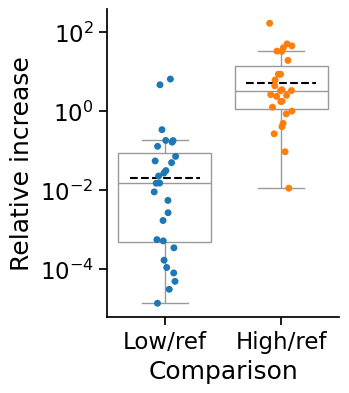

In [685]:
idx = df_rel_increase['Comparison'].isin(['High/ref', 'Low/ref'])
fig, ax = plt.subplots(figsize=(3, 4))
sns.boxplot(df_rel_increase.loc[idx], x = 'Comparison', y = 'Relative increase', color = 'w', fliersize=0)
ax = sns.stripplot(df_rel_increase.loc[idx], x = 'Comparison', y = 'Relative increase', palette='tab10')
ax.axhline(5, xmin=0.6, xmax =0.9, color='k', linestyle='--')
ax.axhline(0.02, xmin=0.1, xmax =0.4, color='k', linestyle='--')
plt.yscale('log')
sns.despine()
plt.savefig('../../figures/2_second_community_assembly_relative_increase.pdf')

In [633]:

df_mean78.loc[(df_mean78['Carbon source'] == 'Acetate 0.02x') & (df_mean78['Species'] == 'At')]

,Species,Carbon source,Mean CFUs/mL,Std CFUs/mL,Abundance rank,Group,Auxotroph,Base carbon source
2,At,Acetate 0.02x,8.966667e+06,1.107532e+07,1.0,1/50x carbon,Prototroph,Acetate


/Users/snorre/miniconda3/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  self._figure.tight_layout(*args, **kwargs)
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_62937/3172555526.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_62937/3172555526.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_62937/3172555526.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipyk

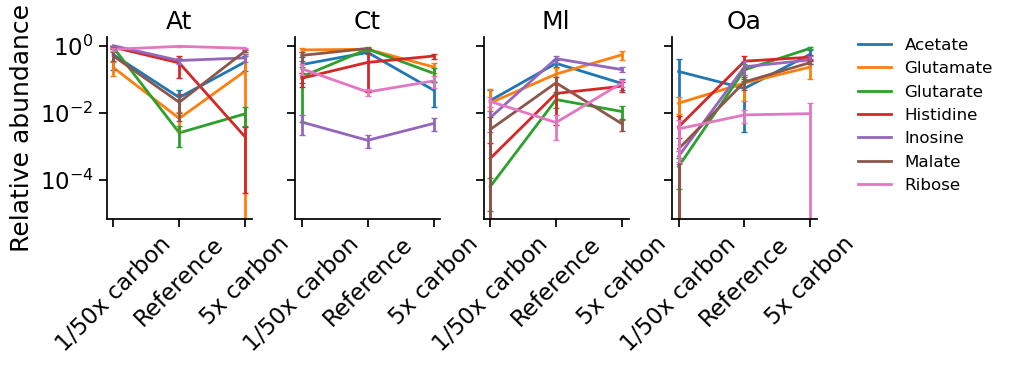

In [621]:
idxg = df_rel78['Group'].isin(['Reference', '1/50x carbon', '5x carbon'])
# Define the desired order for the 'Group' variable
group_order = ['1/50x carbon', 'Reference', '5x carbon']

# Reorder the 'Group' column in the DataFrame
df_rel78['Group'] = pd.Categorical(df_rel78['Group'], categories=group_order, ordered=True)

# fig, ax = plt.subplots(figsize=(2, 6))
g = sns.relplot(df_rel78.loc[idxg], x = 'Group', y = 'Mean rel. population', 
                hue = 'Base carbon source', kind='line', col = 'Species', palette='tab10', 
            legend=True, err_style='bars',
            height=4, 
            lw=2,
            aspect=0.4)#, errorbar=('ci', 'Std CFUs/mL'))
# Add custom error bars manually
for ax, (species, group_data) in zip(g.axes.flat, df_rel78.loc[idxg].groupby('Species')):
    for hue_value, hue_group in group_data.groupby('Base carbon source'):
        # Sort the data by the x-axis variable
        hue_group = hue_group.sort_values(by='Group')

        # Plot the error bars
        ax.errorbar(
            hue_group['Group'],
            hue_group['Mean rel. population'],
            yerr=hue_group['Std rel. population'],  # Use the standard deviation column for error bars
            fmt='none',  # Do not plot additional points
            ecolor=sns.color_palette('tab10')[list(df_rel78.loc[idxg]['Base carbon source'].unique()).index(hue_value)],
            alpha=1,
            elinewidth=2,
            capsize=2
        )

# sns.lineplot(df_rel78.loc[idxg], x = 'Group', y = 'Rel. population', hue = 'Base carbon source', legend=False,err_style='bars')
plt.yscale('log')
for ax in g.axes.flat:
    ax.set_xticklabels(
        ax.get_xticklabels(),  # Replace spaces with line breaks
        rotation=45, ha='center')
    # ax.set_xlim(-0.1, 1.1)
    ax.set_xlabel('')
plt.tight_layout()
# Remove 'Species' from the titles
g.set_titles("{col_name}")  # Only show the value of the 'Species' column
plt.subplots_adjust(wspace=0.3, hspace=0.3)  # Reduce horizontal and vertical spacing
sns.move_legend(g, "upper left", bbox_to_anchor=(0.95, .9), fontsize=12, title='')
g.set_ylabels('Relative abundance')
plt.savefig('../../figures/2_second_community_assembly_relative_abundance_c_more_or_less.pdf')

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_62937/1701970124.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_62937/1701970124.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_62937/1701970124.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_62937/1701970124.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


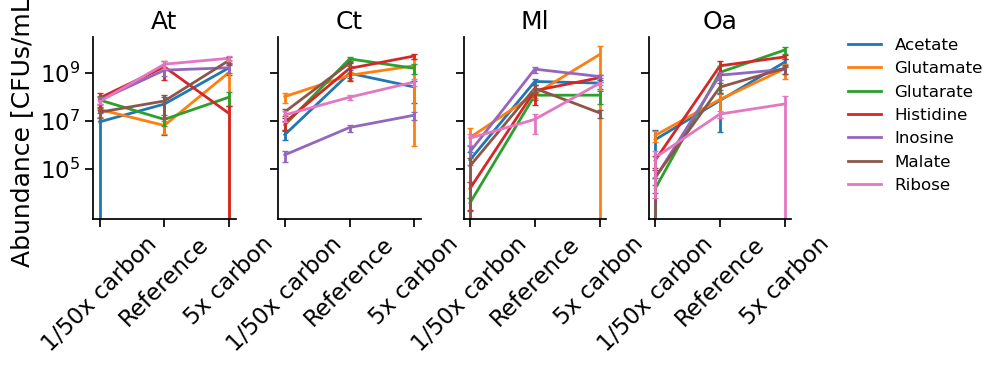

In [622]:
idxg = df_mean78['Group'].isin(['Reference', '1/50x carbon', '5x carbon'])
# Define the desired order for the 'Group' variable
group_order = ['1/50x carbon', 'Reference', '5x carbon']

# Reorder the 'Group' column in the DataFrame
df_mean78['Group'] = pd.Categorical(df_mean78['Group'], categories=group_order, ordered=True)

# fig, ax = plt.subplots(figsize=(2, 6))
g = sns.relplot(df_mean78.loc[idxg], x = 'Group', y = 'Mean CFUs/mL', 
                hue = 'Base carbon source', kind='line', col = 'Species', palette='tab10', 
            legend=True, err_style='bars',
            height=4, 
            lw=2,
            aspect=0.4)#, errorbar=('ci', 'Std CFUs/mL'))
# Add custom error bars manually
for ax, (species, group_data) in zip(g.axes.flat, df_mean78.loc[idxg].groupby('Species')):
    for hue_value, hue_group in group_data.groupby('Base carbon source'):
        # Sort the data by the x-axis variable
        hue_group = hue_group.sort_values(by='Group')

        # Plot the error bars
        ax.errorbar(
            hue_group['Group'],
            hue_group['Mean CFUs/mL'],
            yerr=hue_group['Std CFUs/mL'],  # Use the standard deviation column for error bars
            fmt='none',  # Do not plot additional points
            ecolor=sns.color_palette('tab10')[list(df_mean78.loc[idxg]['Base carbon source'].unique()).index(hue_value)],
            alpha=1,
            elinewidth=2,
            capsize=2
        )

# sns.lineplot(df_mean78.loc[idxg], x = 'Group', y = 'Rel. population', hue = 'Base carbon source', legend=False,err_style='bars')
plt.yscale('log')
for ax in g.axes.flat:
    ax.set_xticklabels(
        ax.get_xticklabels(),  # Replace spaces with line breaks
        rotation=45, ha='center')
    # ax.set_xlim(-0.1, 1.1)
    ax.set_xlabel('')

plt.tight_layout()
# Remove 'Species' from the titles
g.set_titles("{col_name}")  # Only show the value of the 'Species' column
plt.subplots_adjust(wspace=0.3, hspace=0.3)  # Reduce horizontal and vertical spacing
sns.move_legend(g, "upper left", bbox_to_anchor=(0.95, .9), fontsize=12, title='')
g.set_ylabels('Abundance [CFUs/mL]')
g.set(yticks=[1e5, 1e7, 1e9])
plt.savefig('../../figures/2_second_community_assembly_absolute_abundance_c_more_or_less.pdf')